### Validation Notebook

**Changes from original:**
1. **Dataset pivoting** — reshapes long-format (multiple rows per date) to wide format (one row per date, weather columns suffixed by location)
2. **Spread fix** — triple barrier now uses the ECM residual spread (with hedge ratio beta), not the raw log-ratio
3. **`get_bins` fix** — vertical barrier (time-out) now correctly labelled 0 instead of +1/-1
4. **Vertical barrier edge case** — last rows clipped safely instead of silently dropped
5. **Cleanup** — removed unused `pt_sl_` variable in `get_events`

## Step 0 — Load dataset & transform to wide format

We have all the weather variables 3 times (for 3 different locations), so we have 3 rows with the same date. We need to change the dataframe so there is 1 row for each unique date only(for the model to work correctly).

In [2]:
import pandas as pd
import numpy as np

# Load data
raw = pd.read_csv(r"C:\Users\roosd\Downloads\econometrie jaar 3\TIC\Spring2026-TIC\data\merged_prices_weather.csv")

raw['date'] = pd.to_datetime(raw['date'])

# Identify column groups
price_cols   = ['corn_Close', 'corn_Volume', 'corn_log_return',
                'soybean_Close', 'soybean_Volume', 'soybean_log_return']
meta_cols    = ['date', 'Latitude', 'Longitude', 'Location_ID']
weather_cols = [c for c in raw.columns if c not in price_cols + meta_cols]

# Price table: one row per date (prices are identical across locations)
prices = (
    raw.groupby('date')[price_cols]
       .first()
       .reset_index()
)

# Weather table: pivot to wide format(one row per date, separate columns for each location)
raw_weather = raw.dropna(subset=['Location_ID']).copy()
raw_weather['Location_ID'] = raw_weather['Location_ID'].astype(int)
weather_wide = raw.pivot(index='date', columns='Location_ID', values=weather_cols)
weather_wide.columns = [f"{var}_loc{loc}" for var, loc in weather_wide.columns]
weather_wide = weather_wide.reset_index()

# Merge
data = prices.merge(weather_wide, on='date')

# Set date index & deduplicate
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data = data[~data.index.duplicated(keep='first')]
data = data.sort_index()

print(f"Wide dataset shape: {data.shape}")
print(f"Date range: {data.index.min().date()} → {data.index.max().date()}")
print(f"Columns ({len(data.columns)} total):")
print(data.columns.tolist()[:10], "...")  # preview first 10
data.head(3)

Wide dataset shape: (5305, 162)
Date range: 2005-01-03 → 2026-02-02
Columns (162 total):
['corn_Close', 'corn_Volume', 'corn_log_return', 'soybean_Close', 'soybean_Volume', 'soybean_log_return', 'temperature_2m_mean_locnan', 'temperature_2m_mean_loc1.0', 'temperature_2m_mean_loc2.0', 'temperature_2m_mean_loc3.0'] ...


,corn_Close,corn_Volume,corn_log_return,soybean_Close,soybean_Volume,soybean_log_return,temperature_2m_mean_locnan,temperature_2m_mean_loc1.0,temperature_2m_mean_loc2.0,temperature_2m_mean_loc3.0,...,soil_temperature_0_to_7cm_mean_loc2.0,soil_temperature_0_to_7cm_mean_loc3.0,soil_temperature_28_to_100cm_mean_locnan,soil_temperature_28_to_100cm_mean_loc1.0,soil_temperature_28_to_100cm_mean_loc2.0,soil_temperature_28_to_100cm_mean_loc3.0,soil_temperature_7_to_28cm_mean_locnan,soil_temperature_7_to_28cm_mean_loc1.0,soil_temperature_7_to_28cm_mean_loc2.0,soil_temperature_7_to_28cm_mean_loc3.0
date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,201.75,1743.0,0.000000,537.25,47,0.000000,NaN,11.580083,9.055416,6.513833,...,10.184585,5.168000,NaN,5.542584,13.367916,6.813833,NaN,8.771749,10.949168,5.303416
2005-01-04,201.00,1357.0,-0.003724,529.75,54,-0.014058,NaN,4.525917,7.024166,8.643000,...,8.736667,7.170083,NaN,6.175917,13.167916,6.861749,NaN,7.267583,10.107500,6.636750
2005-01-05,201.50,1159.0,0.002484,534.00,37,0.007991,NaN,0.390500,7.551250,5.203417,...,8.428333,4.782584,NaN,6.390499,12.880416,6.942999,NaN,5.090500,9.442917,5.793000


## Step 1 — Cointegration Test & Hedge Ratio (ECM)

Rows available for cointegration: 5303
Cointegration p-value: 0.01588
Hedge Ratio (Beta): 1.0850
Interpretation: A 1% move in Soybeans implies a 1.0850% move in Corn.

ADF Statistic on ECM spread: -3.7477
P-Value: 0.00349
Result: COINTEGRATION DETECTED — spread is mean-reverting.


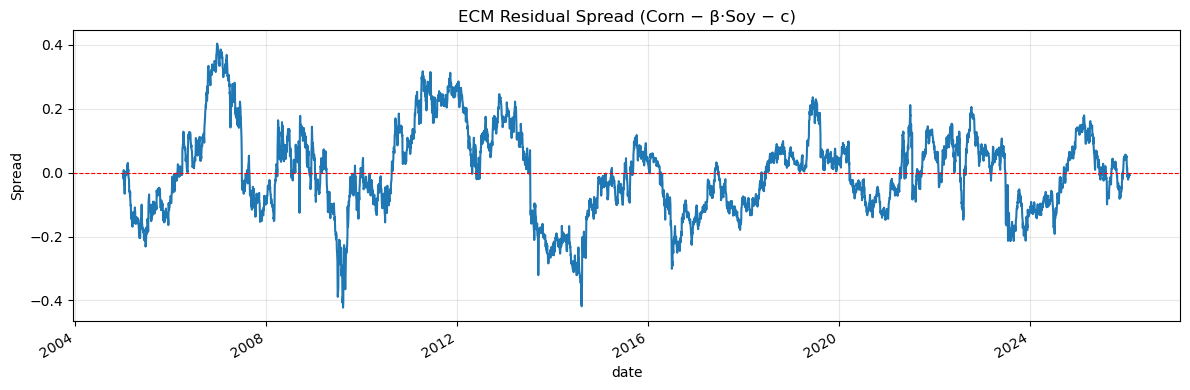

In [11]:
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt

# Take log prices(grow more linear, standard in finance)
model_data = data[['corn_Close', 'soybean_Close']].copy()
model_data = model_data[(model_data > 0).all(axis=1)].dropna()

log_corn = np.log(model_data['corn_Close'])
log_soy  = np.log(model_data['soybean_Close'])

print(f"Rows available for cointegration: {len(model_data)}")

# Engle-Granger cointegration test
# Checks if log(Corn) and log(Soy) have a stationary(no trend) linear combination.
coint_t, p_value, crit_values = ts.coint(log_corn, log_soy)
print(f"Cointegration p-value: {p_value:.5f}")

# OLS for hedge ratio (beta)
# log(Corn) = const + beta * log(Soy) + epsilon
x_const    = sm.add_constant(log_soy)
ols_result = sm.OLS(log_corn, x_const).fit()
beta  = ols_result.params['soybean_Close']
const = ols_result.params['const']

print(f"Hedge Ratio (Beta): {beta:.4f}")
print(f"Interpretation: A 1% move in Soybeans implies a {beta:.4f}% move in Corn.")

# ECM residual spread
# This is the stationary linear combination we trade.
data['ecm_spread'] = np.log(data['corn_Close']) - beta * np.log(data['soybean_Close']) - const

# ADF on the spread (formal test for stationarity)
adf_stat, adf_p, _, _, _, _ = ts.adfuller(data['ecm_spread'].dropna())
print(f"\nADF Statistic on ECM spread: {adf_stat:.4f}")
print(f"P-Value: {adf_p:.5f}")
if adf_p < 0.05:
    print("Result: COINTEGRATION DETECTED — spread is mean-reverting.")
else:
    print("Result: NO COINTEGRATION detected at 5% level.")

# Plot
plt.figure(figsize=(12, 4))
data['ecm_spread'].plot(title='ECM Residual Spread (Corn − β·Soy − c)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.ylabel('Spread')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Engle-Granger Test --> H0: no cointegration

The cointegration p-value is 0.01588<0.05, so we can reject H0 and there is cointegration between corn and soybeans.

## Step 2 — ECM Estimation (Speed of Adjustment)

The **Error Correction Model (ECM)** captures two things simultaneously: how corn and soybean prices move together in the short run, and how quickly they correct back to their long-run equilibrium when the spread deviates.

The model equation is:

$$\Delta\log(\text{Corn}_t) = \gamma \cdot \text{spread}_{t-1} + \delta \cdot \Delta\log(\text{Soy}_t) + \varepsilon_t$$


| Parameter | Name | What it means |
|-----------|------|---------------|
| $\gamma$ | Speed of adjustment | How strongly corn is pulled back toward equilibrium. Must be **negative** — a positive spread (corn expensive) should cause corn to *fall* the next day. Larger magnitude = faster reversion. |
| $\delta$ | Short-run co-movement | How much corn moves *today* just because soy moved today, independent of the spread. Captures the contemporaneous price linkage. |
| $\varepsilon_t$ | Residual | The part of corn's daily move not explained by the model. |

### Key derived quantities

**Half-life of reversion** — derived from $\gamma$:

$$\text{Half-life} = \frac{-\log(2)}{\gamma}$$

This tells you how many trading days it takes for half of any deviation from equilibrium to close. A half-life of 126 days means reversion is slow, which directly informs how wide your triple barrier windows need to be and how long you should expect to hold a position.

**Trading interpretation of $\gamma$:**
- If the spread is large and positive (corn expensive relative to soy), a negative $\gamma$ pulls $\Delta\log(\text{Corn})$ downward — corn falls to restore equilibrium.
- If the spread is large and negative (corn cheap), the same mechanism pushes corn upward.
- The bigger $|\gamma|$, the more aggressively and quickly the market self-corrects.

In [4]:
# ECM: Δlog(Corn) = γ · spread_{t-1} + δ · Δlog(Soy) + ε

dy = np.log(data['corn_Close']).diff().rename('dy')
dx = np.log(data['soybean_Close']).diff().rename('dx')
spread_lag = data['ecm_spread'].shift(1).rename('spread_lag')

ecm_df    = pd.concat([dy, dx, spread_lag], axis=1).dropna()
X_ecm     = sm.add_constant(ecm_df[['spread_lag', 'dx']])
ecm_model = sm.OLS(ecm_df['dy'], X_ecm).fit()

print(ecm_model.summary())

gamma      = ecm_model.params['spread_lag']
gamma_pval = ecm_model.pvalues['spread_lag']

print("\n--- ECM Key Results ---")
print(f"Gamma (Speed of Adjustment): {gamma:.4f}")
print(f"Is Gamma Significant? {'YES' if gamma_pval < 0.05 else 'NO'} (p={gamma_pval:.4f})")

if gamma < 0:
    half_life = -np.log(2) / gamma
    print(f"Half-Life of Reversion: {half_life:.1f} days")
    print(f"Meaning: ~{half_life:.0f} trading days for half of a deviation to close.")

                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     1158.
Date:                Tue, 17 Feb 2026   Prob (F-statistic):               0.00
Time:                        09:27:05   Log-Likelihood:                 14571.
No. Observations:                5301   AIC:                        -2.914e+04
Df Residuals:                    5298   BIC:                        -2.912e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.433e-05      0.000      0.255      0.7

## Step 3 — Triple barrier method
Chapter 3 of "Advances in Financial Machine Learning"

Key fix: barriers are now set on the ECM residual spread (not the raw log-ratio).

In [12]:
# Volatility of the ECM spread (EWMA, span=100)
def get_daily_vol(series, span=100):
    """Exponentially-weighted std of daily changes in the spread."""
    return series.diff().ewm(span=span).std()


daily_vol = get_daily_vol(data['ecm_spread'])


# Vertical barriers (max holding period = 60 trading days)
# FIX: clip instead of drop — last rows get the final available date.
t1_indices = data.index.searchsorted(data.index + pd.Timedelta(days=60))
t1_indices = np.clip(t1_indices, 0, len(data.index) - 1)   # safe clip
t1 = pd.Series(data.index[t1_indices], index=data.index)


# apply_pt_sl_on_t1
def apply_pt_sl_on_t1(close, events, pt_sl, molecule):
    """
    Scan each event's price path and record when (if ever) the
    profit-take (pt) or stop-loss (sl) barrier is first breached.

    Parameters
    ----------
    close     : spread series
    events    : DataFrame with columns ['t1', 'trgt', 'side']
    pt_sl     : [sl_multiplier, pt_multiplier]
    molecule  : index subset to process
    """
    events_ = events.loc[molecule]
    out = events_[['t1']].copy(deep=True)

    pt = pt_sl[1] * events_['trgt'] if pt_sl[1] > 0 else pd.Series(np.nan, index=events_.index)
    sl = -pt_sl[0] * events_['trgt'] if pt_sl[0] > 0 else pd.Series(np.nan, index=events_.index)

    for loc, t1_val in events_['t1'].fillna(close.index[-1]).items():
        path = close[loc:t1_val]
        path = path - close[loc]           # cumulative change from entry
        out.loc[loc, 'sl'] = path[path < sl[loc]].index.min()
        out.loc[loc, 'pt'] = path[path > pt[loc]].index.min()

    return out


# get_events
def get_events(close, t_events, pt_sl, target, min_ret,
               vertical_barrier_times=False, side=None):
    """
    Build an events DataFrame and apply the triple barrier.
    """
    # Filter on minimum volatility
    target = target.loc[t_events]
    target = target[target > min_ret]

    # Vertical barrier
    t1 = vertical_barrier_times if vertical_barrier_times is not False \
         else pd.Series(pd.NaT, index=t_events)

    # Side (default: always long, i.e. 1.0)
    side_ = side.loc[target.index] if side is not None \
            else pd.Series(1.0, index=target.index)

    # Align indices
    common_idx = target.index.intersection(t1.index).intersection(side_.index)
    events = pd.DataFrame({
        't1':   t1.loc[common_idx],
        'trgt': target.loc[common_idx],
        'side': side_.loc[common_idx],
    }).dropna(subset=['trgt'])

    # Apply barriers
    df0 = apply_pt_sl_on_t1(close=close, events=events,
                             pt_sl=pt_sl, molecule=events.index)

    # First barrier touched
    events['t1'] = df0.dropna(how='all').min(axis=1)

    return events


# Run triple barrier
events = get_events(
    close=data['ecm_spread'],    # FIX: use ECM residual spread
    t_events=data.index,
    pt_sl=[1, 1],                # symmetric ±1σ barriers
    target=daily_vol,
    min_ret=0.005,
    vertical_barrier_times=t1,
)

print(f"Events generated: {events.shape}")

Events generated: (5303, 3)


## Step 4 — Label Generation

Key fix: vertical barrier (time-out) is now correctly labelled 0 instead of ±1.

In [13]:
def get_bins(events, close, t1_original):
    """
    Label each event based on which barrier was hit first.

    Returns a DataFrame with:
        ret : realised change in spread from entry to first barrier touch
        bin : +1 (PT hit), -1 (SL hit), 0 (vertical barrier / time-out)

    Parameters
    ----------
    events      : output of get_events
    close       : spread series
    t1_original : the original vertical barrier Series (before overwriting in get_events)
                  used to identify which events timed out
    """
    events_ = events.dropna(subset=['t1'])

    entry_spread = close.loc[events_.index]
    exit_spread  = close.loc[events_['t1']]

    out = pd.DataFrame(index=events_.index)
    out['ret'] = exit_spread.values - entry_spread.values   # change in spread
    out['bin'] = np.sign(out['ret'])                        # raw direction

    # FIX: override with 0 where the vertical barrier was hit
    # i.e. the first-touch time equals the original vertical barrier time
    vertical_hit = events_['t1'] == t1_original.loc[events_.index]
    out.loc[vertical_hit, 'bin'] = 0

    return out


labels = get_bins(events, data['ecm_spread'], t1)

print("Label distribution:")
print(labels['bin'].value_counts().sort_index())

Label distribution:
bin
-1.0    2771
 0.0      10
 1.0    2522
Name: count, dtype: int64


## Step 5 — Purged K-Fold Cross-Validation

In [14]:
from sklearn.model_selection import KFold


class PurgedKFold(KFold):
    """
    K-Fold with purging and embargo to prevent leakage in financial time series.
    (Otherwise an observation labelled at day t has a label determined by what happens
    up to day t+10, which may fall inside the test window.)

    Parameters
    ----------
    n_splits    : number of folds
    t1          : Series mapping each observation's start-time to its end-time
    pct_embargo : fraction of the dataset to embargo after each test fold
    """

    def __init__(self, n_splits=5, t1=None, pct_embargo=0.0):
        super().__init__(n_splits, shuffle=False, random_state=None)
        self.t1 = t1
        self.pct_embargo = pct_embargo

    def split(self, X, y=None, groups=None):
        if not isinstance(X.index, pd.DatetimeIndex):
            raise ValueError("X must have a DatetimeIndex.")

        indices = np.arange(X.shape[0])
        mbrg    = int(X.shape[0] * self.pct_embargo)

        for train_idx, test_idx in super().split(X, y, groups):
            test_start  = X.index[test_idx[0]]
            test_end    = X.index[test_idx[-1]]
            embargo_idx = min(test_idx[-1] + mbrg, X.shape[0] - 1)
            embargo_end = X.index[embargo_idx]

            t1_train = self.t1.iloc[train_idx]
            purged   = []

            for i, t1_val in zip(train_idx, t1_train.values):
                t0_val = X.index[i]
                # Drop if training observation overlaps with test window
                if t1_val >= test_start and t0_val <= test_end:
                    continue
                # Drop if within embargo period after test
                if test_end <= t0_val < embargo_end:
                    continue
                purged.append(i)

            yield np.array(purged), test_idx


# Align X and y on common index
common_idx = labels.index.intersection(data.index)
X          = data.loc[common_idx]
y          = labels.loc[common_idx, 'bin']
t1_reduced = events.loc[common_idx, 't1']

# Run Purged K-Fold
cv = PurgedKFold(n_splits=5, t1=t1_reduced, pct_embargo=0.01)

for i, (train_idx, test_idx) in enumerate(cv.split(X)):
    test_dates = X.index[test_idx]
    print(f"Fold {i+1}: Train size {len(train_idx):5d} | Test size {len(test_idx):5d} "
          f"| Test: {test_dates.min().date()} → {test_dates.max().date()}")

Fold 1: Train size  4190 | Test size  1061 | Test: 2005-01-05 → 2009-03-20
Fold 2: Train size  4187 | Test size  1061 | Test: 2009-03-23 → 2013-06-07
Fold 3: Train size  4186 | Test size  1061 | Test: 2013-06-10 → 2017-08-25
Fold 4: Train size  4189 | Test size  1060 | Test: 2017-08-28 → 2021-11-10
Fold 5: Train size  4240 | Test size  1060 | Test: 2021-11-11 → 2026-02-02


## Step 6 — Simple Backtest

Uses Z-score of the ECM spread with a rolling 30-day window.
Super simple, just to check whether signal exists.

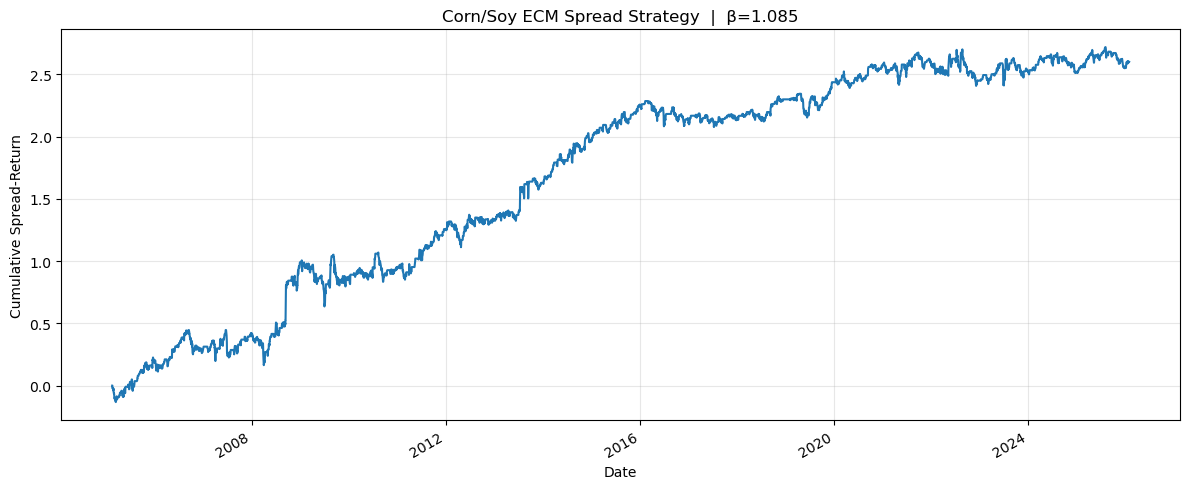

Annualised Sharpe Ratio: 0.57
Note: Sharpe is on spread units, not dollar PnL — treat as a directional sanity check only.


In [18]:
window = 30

bt = data[['ecm_spread']].copy()
bt['roll_mean'] = bt['ecm_spread'].rolling(window).mean()
bt['roll_std']  = bt['ecm_spread'].rolling(window).std()
bt['z_score']   = (bt['ecm_spread'] - bt['roll_mean']) / bt['roll_std']

bt = bt.dropna(subset=['z_score']).copy()

# Signal generation with hold logic
conditions = [
    bt['z_score'] > 1.0,          # Short spread (Corn expensive vs Soy)
    bt['z_score'] < -1.0,         # Long spread  (Corn cheap vs Soy)
    bt['z_score'].abs() < 0.5,    # Exit
]
choices = [-1, 1, 0]

bt['signal']   = np.select(conditions, choices, default=np.nan)
bt['position'] = bt['signal'].ffill().fillna(0)

# PnL as change in spread × position
bt['strategy_ret'] = bt['position'].shift(1) * bt['ecm_spread'].diff()

# Plot
plt.figure(figsize=(12, 5))
bt['strategy_ret'].cumsum().plot()
plt.title(f"Corn/Soy ECM Spread Strategy  |  β={beta:.3f}")
plt.xlabel("Date")
plt.ylabel("Cumulative Spread-Return")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sharpe = (bt['strategy_ret'].mean() / bt['strategy_ret'].std()) * np.sqrt(252)
print(f"Annualised Sharpe Ratio: {sharpe:.2f}")
print("Note: Sharpe is on spread units, not dollar PnL — treat as a directional sanity check only.")

## Step 7 — Export Final Dataset for Feature Selection

Joins the wide-format feature matrix with triple barrier labels. This is the input for the next stage.

In [16]:
# Add ECM spread and Z-score to the feature matrix
data['z_score'] = bt['z_score']
data['ecm_spread_lag1'] = data['ecm_spread'].shift(1)
data['ecm_spread_lag2'] = data['ecm_spread'].shift(2)
data['spread_return']   = data['corn_log_return'] - data['soybean_log_return']

# Merge labels in
feature_df = data.join(labels[['bin', 'ret']], how='inner')
feature_df = feature_df.dropna(subset=['bin'])

print(f"Final feature matrix shape: {feature_df.shape}")
print(f"Label distribution:\n{feature_df['bin'].value_counts().sort_index()}")

# Save to CSV for next stage
feature_df.to_csv("C:\\Users\\roosd\\Downloads\\econometrie jaar 3\\TIC\\Spring2026-TIC\\data\\feature_matrix.csv")
print("\nSaved to feature_matrix.csv — ready for feature selection.")

Final feature matrix shape: (5303, 169)
Label distribution:
bin
-1.0    2771
 0.0      10
 1.0    2522
Name: count, dtype: int64

Saved to feature_matrix.csv — ready for feature selection.
